# Data-Driven Sales Analysis and Market Insights for Nanihaal (Aug 2025 – Feb 2026)

# Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#Load the Excel file
file_path = "nanihaal.xlsx"

data = pd.ExcelFile(file_path)

print(data.sheet_names)

['Monthly sales', 'August Pivot', 'City-wise dynamics', 'September Pivot', 'October Pivot', 'November Pivot', 'December Pivot', 'January Pivot', 'February Pivot', 'Product-wise dynamics', 'Pincode-wise dynamics', "Aug'25", "Septmeber'25", "October'25", "November'25", "December'25", "January'26", "February'26", 'Dump sheet']


# Month-Wise Sales Analysis

In [4]:
df = pd.read_excel(file_path, sheet_name="Monthly sales")

df = df.dropna(how="all")
df = df.rename(columns={"Unnamed: 0":"Metric"})

sales = df[df["Metric"]=="Swiggy sales (in val)"].iloc[0,1:]

months = sales.index.tolist()
revenue = sales.values

sales_df = pd.DataFrame({
    "Month": months,
    "Revenue": revenue
})

print(sales_df)

       Month   Revenue
0     August  640602.0
1  September    840877
2    October  789172.0
3   November  728949.0
4   December  854205.0
5    January  971357.0
6   February  785024.0


# Month-Wise Sales Graph

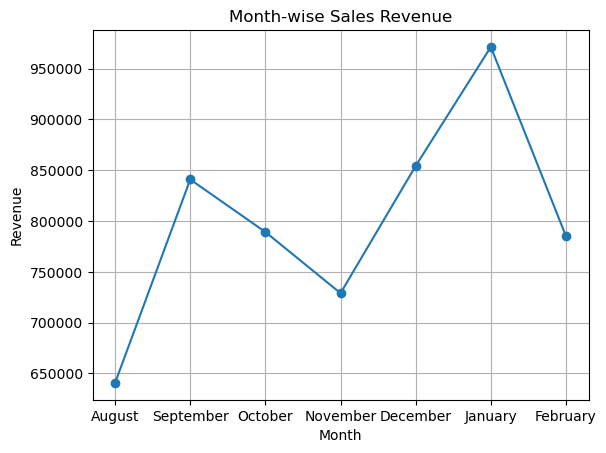

In [5]:
plt.figure()

plt.plot(sales_df["Month"], sales_df["Revenue"], marker="o")

plt.title("Month-wise Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid()

plt.show()

# Month-Wise Orders Analysis

In [6]:
orders = df[df["Metric"]=="Swiggy sales(in vol)"].iloc[0,1:]

orders_df = pd.DataFrame({
    "Month": months,
    "Orders": orders.values
})

print(orders_df)

       Month   Orders
0     August   7295.0
1  September     8981
2    October   9184.0
3   November   8943.0
4   December  10683.0
5    January  11111.0
6   February   9688.0


# Orders Graph

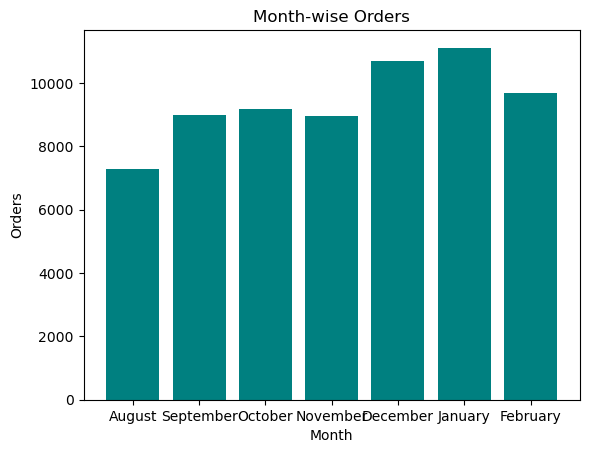

In [7]:
plt.figure()

plt.bar(orders_df["Month"], orders_df["Orders"], color="teal")

plt.title("Month-wise Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.show()

# Average Order Value (AOV)

In [8]:
aov = df[df["Metric"]=="Average GMV"].iloc[0,1:]

aov_df = pd.DataFrame({
    "Month": months,
    "AOV": aov.values
})

print(aov_df)

       Month        AOV
0     August  87.813845
1  September  93.628438
2    October  85.929007
3   November  81.510567
4   December  79.959281
5    January  87.423004
6   February  81.030553


# AOV Graph

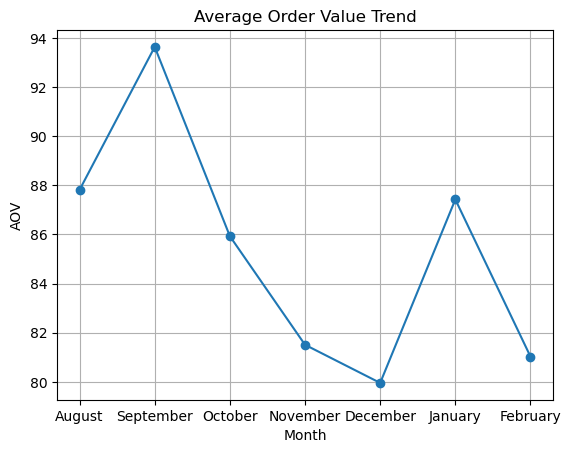

In [9]:
plt.figure()

plt.plot(aov_df["Month"], aov_df["AOV"], marker="o")

plt.title("Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("AOV")

plt.grid()

plt.show()

# City-Wise Analysis

In [10]:
months_sheets = [
"Aug'25",
"Septmeber'25",
"October'25",
"November'25",
"December'25",
"January'26",
"February'26"
]

city_orders = {}

for sheet in months_sheets:
    
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    if "CITY" in df.columns:
        
        city_data = df.groupby("CITY")["UNITS_SOLD"].sum()
        
        for city, value in city_data.items():
            
            if city in city_orders:
                city_orders[city] += value
            else:
                city_orders[city] = value

# Convert City Data to DataFrame

In [11]:
city_df = pd.DataFrame(list(city_orders.items()), columns=["City","Orders"])

city_df = city_df.sort_values(by="Orders", ascending=False)

print(city_df.head(10))

          City   Orders
8        Delhi  13539.0
12     Gurgaon  12117.0
26     Noida 1   6641.0
25       Noida   4234.0
19     Kolkata   3804.0
15      Jaipur   2750.0
37  Chandigarh   2639.0
21     Lucknow   2596.0
11   Faridabad   2119.0
41      Mumbai   2060.0


# Top Cities Graph

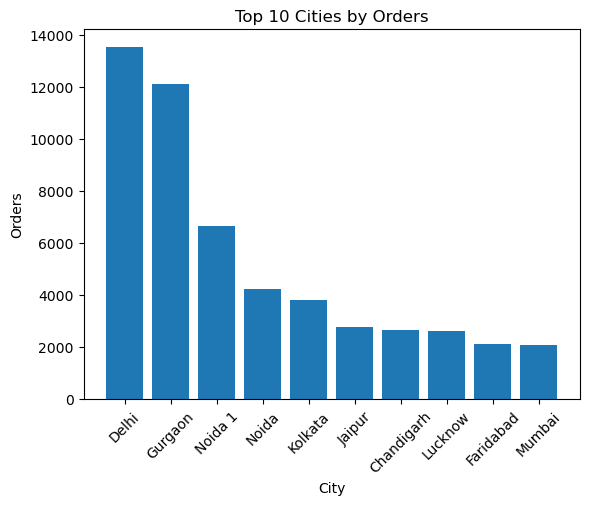

In [12]:
top_cities = city_df.head(10)

plt.figure()

plt.bar(top_cities["City"], top_cities["Orders"])

plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

In [13]:
print("Total Revenue:", sales_df["Revenue"].sum())

print("Average Monthly Revenue:", sales_df["Revenue"].mean())

print("Highest Sales Month:", sales_df.loc[sales_df["Revenue"].idxmax(),"Month"])

print("Lowest Sales Month:", sales_df.loc[sales_df["Revenue"].idxmin(),"Month"])

print("Top City by Orders:", city_df.iloc[0]["City"])

Total Revenue: 5610186.0
Average Monthly Revenue: 801455.1428571428
Highest Sales Month: January
Lowest Sales Month: August
Top City by Orders: Delhi


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "nanihaal.xlsx"

months = [
"Aug'25",
"Septmeber'25",
"October'25",
"November'25",
"December'25",
"January'26",
"February'26"
]

data_list = []

for sheet in months:
    
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    df["MONTH"] = sheet
    
    data_list.append(df)

full_data = pd.concat(data_list)

print(full_data.head())

   Column1     BRAND         ORDERED_DATE       CITY     AREA_NAME   STORE_ID  \
0      0.0  nanihaal  2025-08-08 00:00:00  Moradabad    budh bazar  1402272.0   
1      1.0  nanihaal  2025-08-08 00:00:00      Noida     raj nagar  1404166.0   
2      2.0  nanihaal  2025-08-08 00:00:00    Gurgaon     sector-14  1394451.0   
3   2869.0  nanihaal  2025-08-01 00:00:00      Delhi   ashok vihar  1402052.0   
4      4.0  nanihaal  2025-08-08 00:00:00     Jaipur  pratap nagar  1395724.0   

                L1_CATEGORY   L2_CATEGORY  L3_CATEGORY  \
0  masala, pickle and papad  whole spices        saunf   
1  masala, pickle and papad  whole spices     tamarind   
2  masala, pickle and papad  whole spices  methi seeds   
3  masala, pickle and papad  whole spices        saunf   
4  masala, pickle and papad  whole spices      kalonji   

                PRODUCT_NAME  ... COMBO_UNITS_SOLD  BASE_MRP UNITS_SOLD  \
0        nanihaal moti saunf  ...              NaN     105.0        1.0   
1  nanihaal im

In [15]:
top_products = full_data.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum()

top_products = top_products.sort_values(ascending=False).head(5)

print(top_products)

PRODUCT_NAME
nanihaal imli ( seedless)    26461.0
nanihaal safed til            4649.0
nanihaal kaali sarson         3585.0
nanihaal sabut methi dana     3555.0
nanihaal hari elaichi         3389.0
Name: UNITS_SOLD, dtype: float64


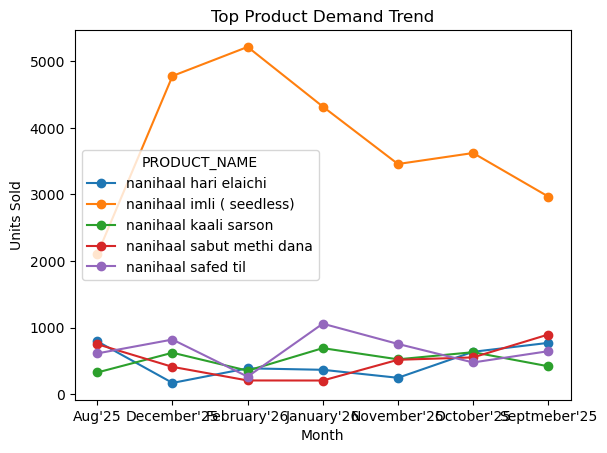

In [16]:
product_trend = full_data.groupby(["MONTH","PRODUCT_NAME"])["UNITS_SOLD"].sum()

product_trend = product_trend.reset_index()

top_list = top_products.index.tolist()

product_trend = product_trend[product_trend["PRODUCT_NAME"].isin(top_list)]

pivot_table = product_trend.pivot(index="MONTH",columns="PRODUCT_NAME",values="UNITS_SOLD")

pivot_table.plot(marker="o")

plt.title("Top Product Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.show()

# City vs Product Demand Heatmap

In [17]:
city_product = full_data.pivot_table(
    
    values="UNITS_SOLD",
    index="CITY",
    columns="PRODUCT_NAME",
    aggfunc="sum"
)

print(city_product.head())

PRODUCT_NAME  nanihaal ajwain  nanihaal black kaali rai  \
CITY                                                      
Agra                     64.0                      10.0   
Ahmedabad                 NaN                       NaN   
Aligarh                  66.0                      25.0   
Amritsar                  NaN                       NaN   
Bangalore                 NaN                       NaN   

PRODUCT_NAME  nanihaal black pepper ( whole)  nanihaal dal cheeni  \
CITY                                                                
Agra                                     1.0                 15.0   
Ahmedabad                                8.0                  NaN   
Aligarh                                  5.0                 39.0   
Amritsar                                 NaN                  NaN   
Bangalore                               28.0                  NaN   

PRODUCT_NAME  nanihaal garam masala  nanihaal gond kateera  \
CITY                                    

In [18]:
top_cities = full_data.groupby("CITY")["UNITS_SOLD"].sum()

top_cities = top_cities.sort_values(ascending=False).head(10)

city_product = city_product.loc[top_cities.index]

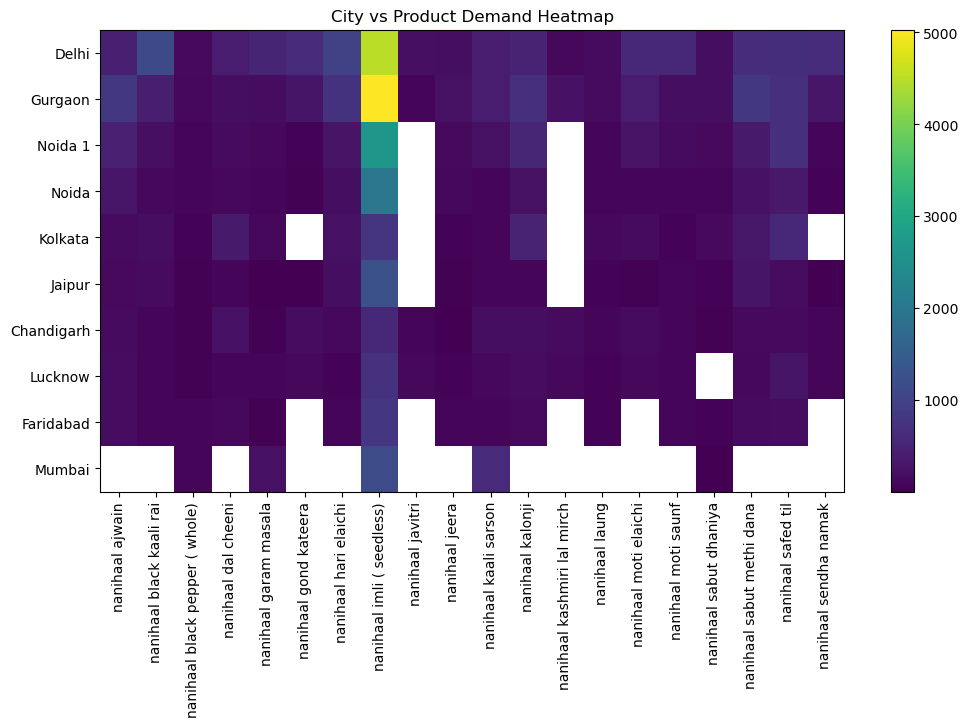

In [19]:
plt.figure(figsize=(12,6))

plt.imshow(city_product, aspect="auto")

plt.colorbar()

plt.xticks(range(len(city_product.columns)), city_product.columns, rotation=90)

plt.yticks(range(len(city_product.index)), city_product.index)

plt.title("City vs Product Demand Heatmap")

plt.show()

In [20]:
file_path = "nanihaal.xlsx"

months = [
"Aug'25",
"Septmeber'25",
"October'25",
"November'25",
"December'25",
"January'26",
"February'26"
]

data_list = []

for sheet in months:
    
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    data_list.append(df)

data = pd.concat(data_list)

In [21]:
product_priority = data.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum()

product_priority = product_priority.sort_values(ascending=False)

product_priority = product_priority.reset_index()

product_priority["Priority Rank"] = range(1, len(product_priority)+1)

print(product_priority)

                      PRODUCT_NAME  UNITS_SOLD  Priority Rank
0        nanihaal imli ( seedless)     26461.0              1
1               nanihaal safed til      4649.0              2
2            nanihaal kaali sarson      3585.0              3
3        nanihaal sabut methi dana      3555.0              4
4            nanihaal hari elaichi      3389.0              5
5                 nanihaal kalonji      3329.0              6
6                  nanihaal ajwain      3252.0              7
7         nanihaal black kaali rai      2679.0              8
8            nanihaal garam masala      2106.0              9
9            nanihaal moti elaichi      1903.0             10
10             nanihaal dal cheeni      1882.0             11
11             nanihaal moti saunf      1599.0             12
12           nanihaal gond kateera      1298.0             13
13           nanihaal sendha namak      1285.0             14
14  nanihaal black pepper ( whole)       997.0             15
15      

In [22]:
product_priority.to_excel("product_priority_ranking.xlsx", index=False)

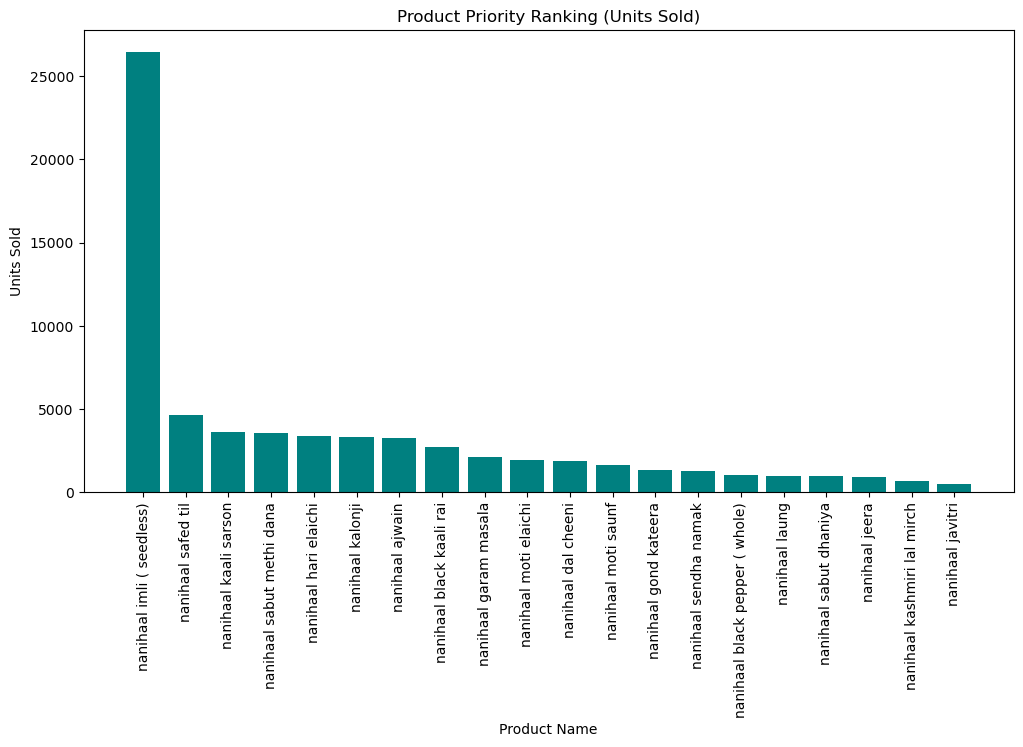

In [23]:
plt.figure(figsize=(12,6))

plt.bar(product_priority["PRODUCT_NAME"], product_priority["UNITS_SOLD"], color="teal")

plt.title("Product Priority Ranking (Units Sold)")
plt.xlabel("Product Name")
plt.ylabel("Units Sold")

plt.xticks(rotation=90)

plt.show()

In [24]:
file_path = "nanihaal.xlsx"

months = [
"Aug'25",
"Septmeber'25",
"October'25",
"November'25",
"December'25",
"January'26",
"February'26"
]

data_list = []

for sheet in months:
    
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    data_list.append(df)

data = pd.concat(data_list)

In [25]:
product_revenue = data.groupby("PRODUCT_NAME")["GMV"].sum()

product_revenue = product_revenue.sort_values(ascending=False)

product_revenue = product_revenue.reset_index()

print(product_revenue)

                      PRODUCT_NAME        GMV
0        nanihaal imli ( seedless)  1760659.0
1            nanihaal hari elaichi   721240.0
2            nanihaal moti elaichi   479715.0
3            nanihaal garam masala   400102.0
4               nanihaal safed til   288215.0
5                 nanihaal kalonji   240118.0
6   nanihaal black pepper ( whole)   239232.0
7                  nanihaal ajwain   224856.0
8              nanihaal moti saunf   167895.0
9                   nanihaal jeera   157930.0
10       nanihaal sabut methi dana   142200.0
11             nanihaal dal cheeni   141750.0
12                  nanihaal laung   128845.0
13        nanihaal black kaali rai   128584.0
14           nanihaal kaali sarson   107598.0
15           nanihaal gond kateera    91490.0
16                nanihaal javitri    71610.0
17          nanihaal sabut dhaniya    46545.0
18           nanihaal sendha namak    38216.0
19     nanihaal kashmiri lal mirch    33756.0


In [26]:
total_revenue = product_revenue["GMV"].sum()

product_revenue["Revenue %"] = (product_revenue["GMV"] / total_revenue) * 100

product_revenue["Cumulative %"] = product_revenue["Revenue %"].cumsum()

In [27]:
def abc_category(x):
    
    if x <= 80:
        return "A"
    
    elif x <= 95:
        return "B"
    
    else:
        return "C"

product_revenue["Category"] = product_revenue["Cumulative %"].apply(abc_category)

print(product_revenue)

                      PRODUCT_NAME        GMV  Revenue %  Cumulative %  \
0        nanihaal imli ( seedless)  1760659.0  31.381186     31.381186   
1            nanihaal hari elaichi   721240.0  12.855054     44.236240   
2            nanihaal moti elaichi   479715.0   8.550222     52.786462   
3            nanihaal garam masala   400102.0   7.131236     59.917698   
4               nanihaal safed til   288215.0   5.137013     65.054711   
5                 nanihaal kalonji   240118.0   4.279754     69.334465   
6   nanihaal black pepper ( whole)   239232.0   4.263962     73.598428   
7                  nanihaal ajwain   224856.0   4.007731     77.606159   
8              nanihaal moti saunf   167895.0   2.992484     80.598643   
9                   nanihaal jeera   157930.0   2.814873     83.413516   
10       nanihaal sabut methi dana   142200.0   2.534508     85.948024   
11             nanihaal dal cheeni   141750.0   2.526488     88.474511   
12                  nanihaal laung   1

# Visualization (Pareto Chart)

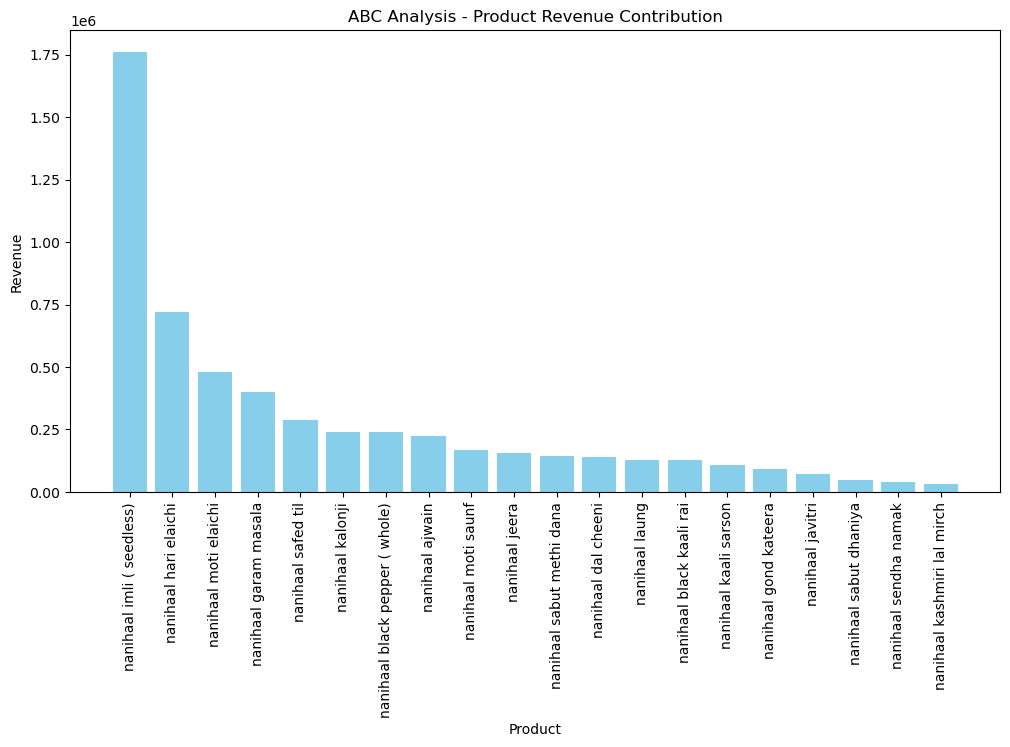

In [28]:
plt.figure(figsize=(12,6))

plt.bar(product_revenue["PRODUCT_NAME"], product_revenue["GMV"], color="skyblue")

plt.xticks(rotation=90)

plt.title("ABC Analysis - Product Revenue Contribution")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.show()

In [29]:
file_path = "nanihaal.xlsx"

months = [
"Aug'25",
"Septmeber'25",
"October'25",
"November'25",
"December'25",
"January'26",
"February'26"
]

data_list = []

for sheet in months:
    
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    df["MONTH"] = sheet
    
    data_list.append(df)

data = pd.concat(data_list)

print(data.head())

   Column1     BRAND         ORDERED_DATE       CITY     AREA_NAME   STORE_ID  \
0      0.0  nanihaal  2025-08-08 00:00:00  Moradabad    budh bazar  1402272.0   
1      1.0  nanihaal  2025-08-08 00:00:00      Noida     raj nagar  1404166.0   
2      2.0  nanihaal  2025-08-08 00:00:00    Gurgaon     sector-14  1394451.0   
3   2869.0  nanihaal  2025-08-01 00:00:00      Delhi   ashok vihar  1402052.0   
4      4.0  nanihaal  2025-08-08 00:00:00     Jaipur  pratap nagar  1395724.0   

                L1_CATEGORY   L2_CATEGORY  L3_CATEGORY  \
0  masala, pickle and papad  whole spices        saunf   
1  masala, pickle and papad  whole spices     tamarind   
2  masala, pickle and papad  whole spices  methi seeds   
3  masala, pickle and papad  whole spices        saunf   
4  masala, pickle and papad  whole spices      kalonji   

                PRODUCT_NAME  ... COMBO_UNITS_SOLD  BASE_MRP UNITS_SOLD  \
0        nanihaal moti saunf  ...              NaN     105.0        1.0   
1  nanihaal im

In [30]:
product_month_sales = data.groupby(["PRODUCT_NAME","MONTH"])["UNITS_SOLD"].sum().reset_index()

print(product_month_sales.head())

      PRODUCT_NAME        MONTH  UNITS_SOLD
0  nanihaal ajwain       Aug'25       561.0
1  nanihaal ajwain  December'25       335.0
2  nanihaal ajwain  February'26       284.0
3  nanihaal ajwain   January'26       537.0
4  nanihaal ajwain  November'25       424.0


# Create a Pivot Table

In [31]:
product_pivot = product_month_sales.pivot(
    
    index="MONTH",
    
    columns="PRODUCT_NAME",
    
    values="UNITS_SOLD"
)

print(product_pivot)

PRODUCT_NAME  nanihaal ajwain  nanihaal black kaali rai  \
MONTH                                                     
Aug'25                  561.0                     474.0   
December'25             335.0                     456.0   
February'26             284.0                     247.0   
January'26              537.0                     366.0   
November'25             424.0                     442.0   
October'25              557.0                     329.0   
Septmeber'25            554.0                     365.0   

PRODUCT_NAME  nanihaal black pepper ( whole)  nanihaal dal cheeni  \
MONTH                                                               
Aug'25                                 107.0                217.0   
December'25                            145.0                303.0   
February'26                            117.0                211.0   
January'26                             207.0                316.0   
November'25                            118.0          

# Plot Demand Trend for Top Products

In [32]:
top_products = data.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum()

top_products = top_products.sort_values(ascending=False).head(5)

top_list = top_products.index.tolist()

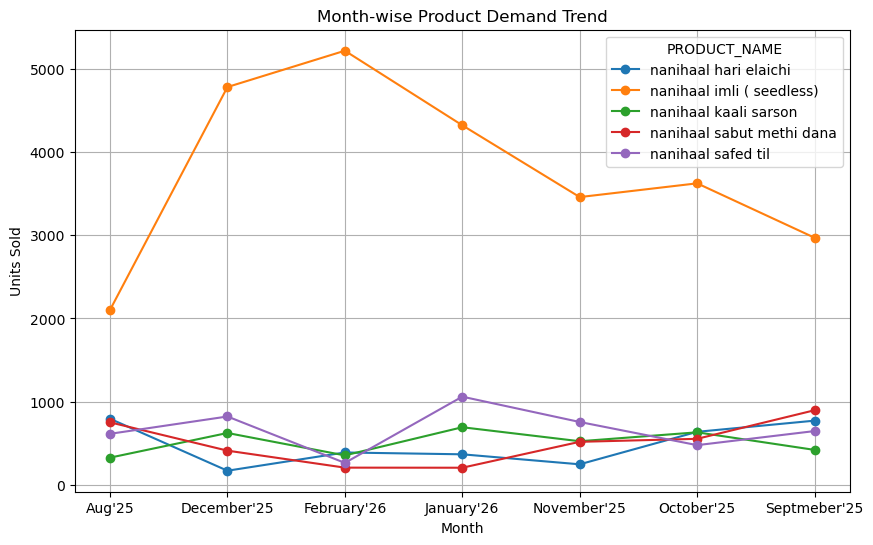

In [33]:
product_trend = product_month_sales[product_month_sales["PRODUCT_NAME"].isin(top_list)]

pivot_trend = product_trend.pivot(
    
    index="MONTH",
    
    columns="PRODUCT_NAME",
    
    values="UNITS_SOLD"
)

pivot_trend.plot(marker="o", figsize=(10,6))

plt.title("Month-wise Product Demand Trend")

plt.xlabel("Month")

plt.ylabel("Units Sold")

plt.grid()

plt.show()

In [34]:
file_path = "nanihaal.xlsx"

months = [
"Aug'25",
"Septmeber'25",
"October'25",
"November'25",
"December'25",
"January'26",
"February'26"
]

data_list = []

for sheet in months:
    
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    df["MONTH"] = sheet
    
    data_list.append(df)

data = pd.concat(data_list)

print(data.head())

   Column1     BRAND         ORDERED_DATE       CITY     AREA_NAME   STORE_ID  \
0      0.0  nanihaal  2025-08-08 00:00:00  Moradabad    budh bazar  1402272.0   
1      1.0  nanihaal  2025-08-08 00:00:00      Noida     raj nagar  1404166.0   
2      2.0  nanihaal  2025-08-08 00:00:00    Gurgaon     sector-14  1394451.0   
3   2869.0  nanihaal  2025-08-01 00:00:00      Delhi   ashok vihar  1402052.0   
4      4.0  nanihaal  2025-08-08 00:00:00     Jaipur  pratap nagar  1395724.0   

                L1_CATEGORY   L2_CATEGORY  L3_CATEGORY  \
0  masala, pickle and papad  whole spices        saunf   
1  masala, pickle and papad  whole spices     tamarind   
2  masala, pickle and papad  whole spices  methi seeds   
3  masala, pickle and papad  whole spices        saunf   
4  masala, pickle and papad  whole spices      kalonji   

                PRODUCT_NAME  ... COMBO_UNITS_SOLD  BASE_MRP UNITS_SOLD  \
0        nanihaal moti saunf  ...              NaN     105.0        1.0   
1  nanihaal im

In [35]:
total_revenue = data["GMV"].sum()

total_orders = data["UNITS_SOLD"].sum()

avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 7881207.0
Total Orders: 92993.0
Average Order Value: 84.75


# Month-wise Sales Trend

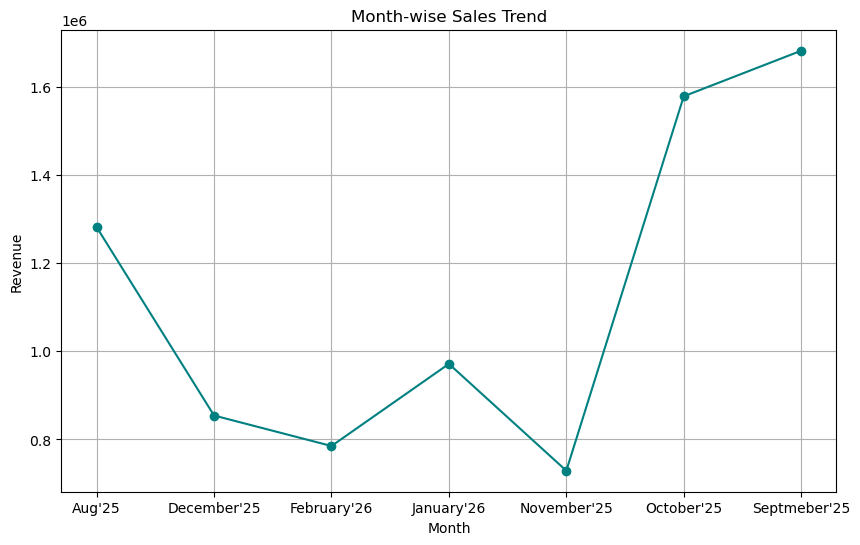

In [36]:
monthly_sales = data.groupby("MONTH")["GMV"].sum().reset_index()

plt.figure(figsize=(10,6))

plt.plot(monthly_sales["MONTH"], monthly_sales["GMV"], marker="o", color="teal")

plt.title("Month-wise Sales Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid()

plt.show()

# Top Cities by Orders

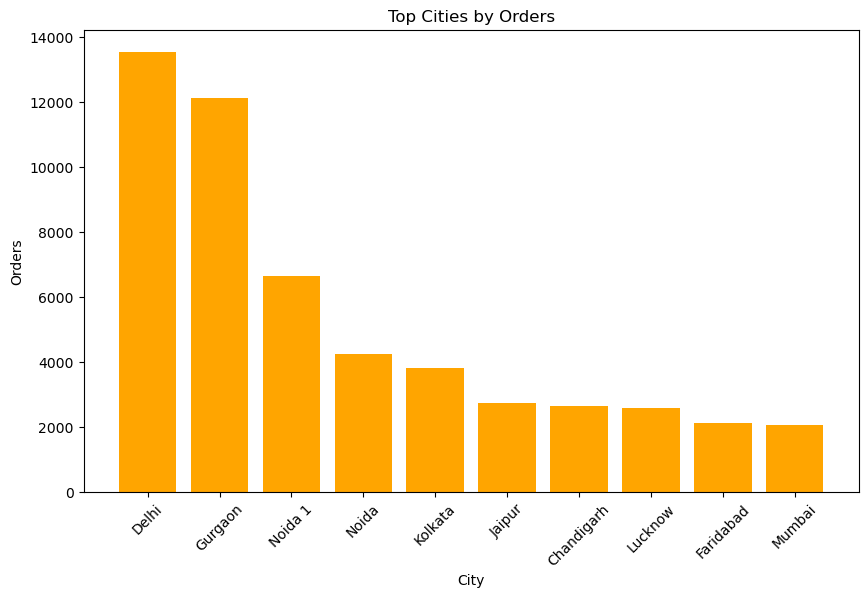

In [37]:
city_sales = data.groupby("CITY")["UNITS_SOLD"].sum()

city_sales = city_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.bar(city_sales.index, city_sales.values, color="orange")

plt.title("Top Cities by Orders")

plt.xlabel("City")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

# Top Products Analysis

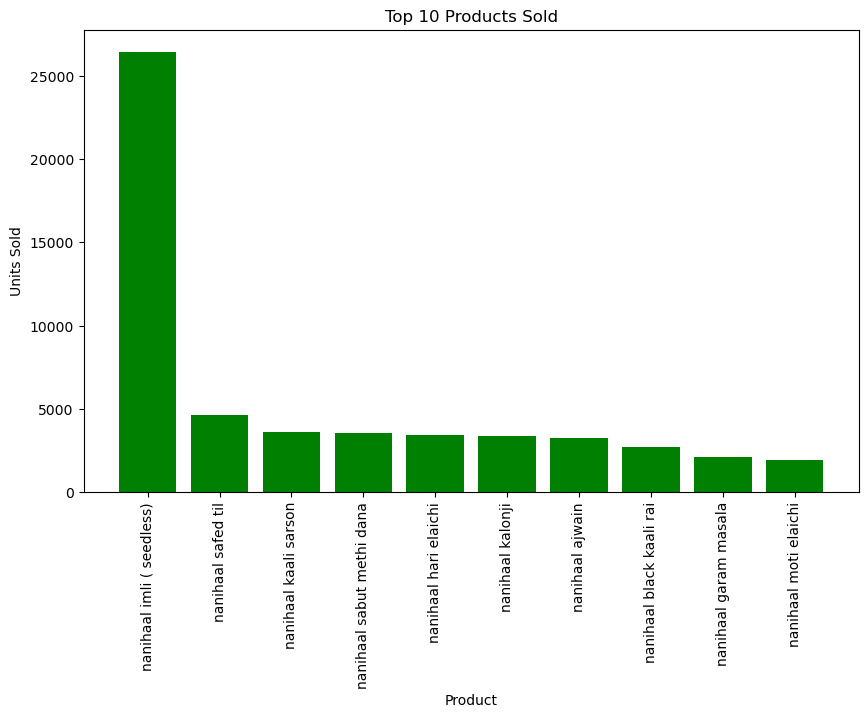

In [38]:
product_sales = data.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum()

product_sales = product_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.bar(product_sales.index, product_sales.values, color="green")

plt.title("Top 10 Products Sold")

plt.xlabel("Product")

plt.ylabel("Units Sold")

plt.xticks(rotation=90)

plt.show()

# Product–City Demand Matrix

In [39]:
city_product_matrix = data.pivot_table(

    values="UNITS_SOLD",

    index="CITY",

    columns="PRODUCT_NAME",

    aggfunc="sum"

)

top_cities = data.groupby("CITY")["UNITS_SOLD"].sum().sort_values(ascending=False).head(10)

city_product_matrix = city_product_matrix.loc[top_cities.index]

# Heatmap Visualization

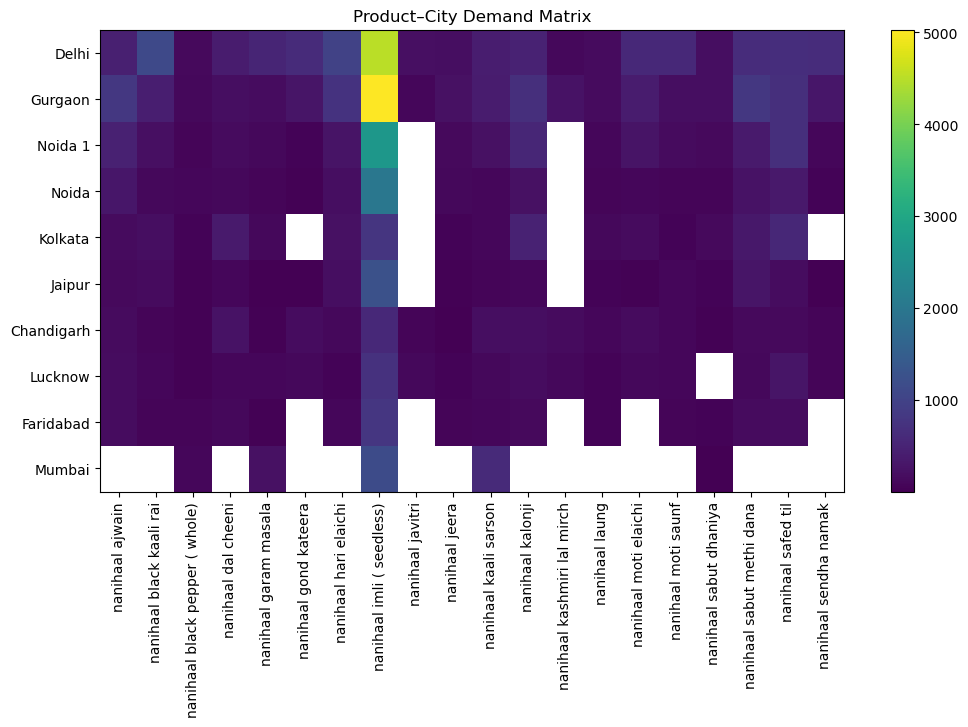

In [40]:
plt.figure(figsize=(12,6))

plt.imshow(city_product_matrix, aspect="auto")

plt.colorbar()

plt.xticks(range(len(city_product_matrix.columns)), city_product_matrix.columns, rotation=90)

plt.yticks(range(len(city_product_matrix.index)), city_product_matrix.index)

plt.title("Product–City Demand Matrix")

plt.show()

# August Month sales Analysis.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "nanihaal.xlsx"

august = pd.read_excel(file_path, sheet_name="Aug'25")

print(august.head())

   Column1     BRAND ORDERED_DATE       CITY     AREA_NAME   STORE_ID  \
0      0.0  nanihaal   2025-08-08  Moradabad    budh bazar  1402272.0   
1      1.0  nanihaal   2025-08-08      Noida     raj nagar  1404166.0   
2      2.0  nanihaal   2025-08-08    Gurgaon     sector-14  1394451.0   
3   2869.0  nanihaal   2025-08-01      Delhi   ashok vihar  1402052.0   
4      4.0  nanihaal   2025-08-08     Jaipur  pratap nagar  1395724.0   

                L1_CATEGORY   L2_CATEGORY  L3_CATEGORY  \
0  masala, pickle and papad  whole spices        saunf   
1  masala, pickle and papad  whole spices     tamarind   
2  masala, pickle and papad  whole spices  methi seeds   
3  masala, pickle and papad  whole spices        saunf   
4  masala, pickle and papad  whole spices      kalonji   

                PRODUCT_NAME  ... ITEM_CODE  COMBO COMBO_ITEM_CODE  \
0        nanihaal moti saunf  ...  129595.0     No             NaN   
1  nanihaal imli ( seedless)  ...  513420.0     No             NaN   
2 

# August Key Metrics

In [42]:
total_revenue_aug = august["GMV"].sum()

total_orders_aug = august["UNITS_SOLD"].sum()

avg_order_value_aug = total_revenue_aug / total_orders_aug

print("August Revenue:", total_revenue_aug)
print("August Orders:", total_orders_aug)
print("August AOV:", round(avg_order_value_aug,2))

August Revenue: 1281574.0
August Orders: 7295.0
August AOV: 175.68
